# Painel de Análise de Vendas com Visualização de Dados
Notebook `painel_vendas.ipynb` — análise de vendas de uma empresa varejista usando **pandas, numpy, matplotlib e seaborn**.

## Etapa 1 — Preparação e Importação de Dados
### 1) Importação das bibliotecas

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### 2) Carregamento do CSV `vendas.csv`
Se o arquivo `vendas.csv` não existir (por exemplo, num Colab novo), a célula abaixo **cria um dataset fictício**
com as colunas `data, loja, produto, quantidade, preco_unitario`. Alguns valores são removidos de propósito
para exercitarmos o tratamento de nulos (item 5).

> Observação: o enunciado pede análises por **região** (item 13) e por **categoria** (item 15), então o dataset fictício
> também traz as colunas `regiao` e `categoria`. Se você usar um CSV próprio sem elas, veja o mapeamento na célula seguinte.

In [2]:
if not os.path.exists('vendas.csv'):
    rng = np.random.default_rng(42)
    n = 600

    lojas = {  # loja -> região
        'Loja Centro': 'Sudeste',
        'Loja Norte': 'Norte',
        'Loja Sul': 'Sul',
        'Loja Shopping': 'Sudeste',
        'Loja Litoral': 'Nordeste',
    }
    produtos = {  # produto -> (categoria, preço base)
        'Notebook': ('Eletrônicos', 3200),
        'Smartphone': ('Eletrônicos', 1800),
        'Fone de Ouvido': ('Acessórios', 150),
        'Mouse': ('Acessórios', 80),
        'Teclado': ('Acessórios', 120),
        'Monitor': ('Eletrônicos', 950),
        'Cadeira Gamer': ('Móveis', 1100),
        'Mesa de Escritório': ('Móveis', 700),
    }

    datas = pd.to_datetime('2025-01-01') + pd.to_timedelta(rng.integers(0, 365, n), unit='D')
    loja = rng.choice(list(lojas), n)
    produto = rng.choice(list(produtos), n)
    quantidade = rng.integers(1, 8, n).astype(float)
    preco = np.array([produtos[p][1] for p in produto]) * rng.normal(1, 0.12, n)

    df_fake = pd.DataFrame({
        'data': datas.strftime('%Y-%m-%d'),
        'loja': loja,
        'regiao': [lojas[l] for l in loja],
        'produto': produto,
        'categoria': [produtos[p][0] for p in produto],
        'quantidade': quantidade,
        'preco_unitario': preco.round(2),
    }).sort_values('data')

    # introduz valores ausentes para o item 5
    df_fake.loc[df_fake.sample(20, random_state=1).index, 'preco_unitario'] = np.nan
    df_fake.loc[df_fake.sample(15, random_state=2).index, 'quantidade'] = np.nan
    df_fake.to_csv('vendas.csv', index=False)
    print('vendas.csv criado.')

df = pd.read_csv('vendas.csv')
df['data'] = pd.to_datetime(df['data'])      # converte para datetime
df.head()

,data,loja,regiao,produto,categoria,quantidade,preco_unitario
0,2025-01-02,Loja Sul,Sul,Fone de Ouvido,Acessórios,5.0,NaN
1,2025-01-03,Loja Centro,Sudeste,Mesa de Escritório,Móveis,2.0,755.61
2,2025-01-03,Loja Centro,Sudeste,Cadeira Gamer,Móveis,5.0,991.79
3,2025-01-03,Loja Shopping,Sudeste,Teclado,Acessórios,1.0,125.40
4,2025-01-04,Loja Norte,Norte,Smartphone,Eletrônicos,2.0,1522.14


In [3]:
# Caso o seu CSV não tenha 'regiao'/'categoria', descomente e ajuste os mapeamentos:
# df['regiao'] = df['loja'].map({'Loja A': 'Sul', 'Loja B': 'Norte'})
# df['categoria'] = df['produto'].map({'Produto X': 'Categoria 1'})
df.dtypes

data              datetime64[us]
loja                         str
regiao                       str
produto                      str
categoria                    str
quantidade               float64
preco_unitario           float64
dtype: object

### 3) Coluna `faturamento` = quantidade × preco_unitario

In [4]:
df['faturamento'] = df['quantidade'] * df['preco_unitario']
df.head()

,data,loja,regiao,produto,categoria,quantidade,preco_unitario,faturamento
0,2025-01-02,Loja Sul,Sul,Fone de Ouvido,Acessórios,5.0,NaN,NaN
1,2025-01-03,Loja Centro,Sudeste,Mesa de Escritório,Móveis,2.0,755.61,1511.22
2,2025-01-03,Loja Centro,Sudeste,Cadeira Gamer,Móveis,5.0,991.79,4958.95
3,2025-01-03,Loja Shopping,Sudeste,Teclado,Acessórios,1.0,125.40,125.40
4,2025-01-04,Loja Norte,Norte,Smartphone,Eletrônicos,2.0,1522.14,3044.28


### 4) Integridade do dataset

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   data            600 non-null    datetime64[us]
 1   loja            600 non-null    str           
 2   regiao          600 non-null    str           
 3   produto         600 non-null    str           
 4   categoria       600 non-null    str           
 5   quantidade      585 non-null    float64       
 6   preco_unitario  580 non-null    float64       
 7   faturamento     565 non-null    float64       
dtypes: datetime64[us](1), float64(3), str(4)
memory usage: 37.6 KB


In [6]:
df.isnull().sum()

data               0
loja               0
regiao             0
produto            0
categoria          0
quantidade        15
preco_unitario    20
faturamento       35
dtype: int64

In [7]:
df.describe()

,data,quantidade,preco_unitario,faturamento
count,600,585.000000,580.000000,565.000000
mean,2025-07-02 04:12:00,3.955556,994.258810,3949.875451
min,2025-01-02 00:00:00,1.000000,52.480000,64.500000
25%,2025-03-31 18:00:00,2.000000,129.770000,532.680000
50%,2025-06-30 12:00:00,4.000000,754.215000,2020.320000
75%,2025-10-05 06:00:00,6.000000,1293.852500,5155.140000
max,2025-12-31 00:00:00,7.000000,4319.070000,25000.570000
std,NaN,2.008051,1012.763671,4991.245227


### 5) Tratamento de nulos
Preços e quantidades faltantes são substituídos pela **média da respectiva coluna**.
Como o `faturamento` calculado no item 3 ficou nulo nessas linhas, ele é recalculado em seguida.

In [8]:
df['preco_unitario'] = df['preco_unitario'].fillna(df['preco_unitario'].mean())
df['quantidade'] = df['quantidade'].fillna(df['quantidade'].mean())

# recalcula o faturamento com os dados já tratados
df['faturamento'] = df['quantidade'] * df['preco_unitario']

print(df.isnull().sum())

data              0
loja              0
regiao            0
produto           0
categoria         0
quantidade        0
preco_unitario    0
faturamento       0
dtype: int64


## Etapa 2 — Análise Exploratória e Estatísticas
### 6) Faturamento total por loja (maior → menor)

In [9]:
fat_loja = df.groupby('loja')['faturamento'].sum().sort_values(ascending=False)
fat_loja

loja
Loja Shopping    542375.188743
Loja Centro      492269.844144
Loja Sul         482484.899893
Loja Litoral     423389.886638
Loja Norte       411974.382548
Name: faturamento, dtype: float64

### 7) Ticket médio por loja (faturamento ÷ número de vendas)

In [10]:
ticket = (df.groupby('loja')['faturamento'].sum() / df.groupby('loja')['faturamento'].count())
ticket = ticket.sort_values(ascending=False).rename('ticket_medio')
ticket.round(2)

loja
Loja Norte       4291.40
Loja Shopping    4140.27
Loja Centro      4035.00
Loja Litoral     3618.72
Loja Sul         3600.63
Name: ticket_medio, dtype: float64

### 8) Cinco produtos mais vendidos em quantidade

In [11]:
top5 = df.groupby('produto')['quantidade'].sum().sort_values(ascending=False).head(5)
top5

produto
Mesa de Escritório    328.911111
Teclado               319.911111
Mouse                 314.911111
Notebook              313.000000
Fone de Ouvido        287.911111
Name: quantidade, dtype: float64

### 10) Coluna `mes` extraída da data
(feito antes do item 9 porque ele facilita os agrupamentos; também criamos `ano_mes` para não misturar anos diferentes)

In [12]:
df['mes'] = df['data'].dt.month
df['ano_mes'] = df['data'].dt.to_period('M')
df[['data', 'mes', 'ano_mes']].head()

,data,mes,ano_mes
0,2025-01-02,1,2025-01
1,2025-01-03,1,2025-01
2,2025-01-03,1,2025-01
3,2025-01-03,1,2025-01
4,2025-01-04,1,2025-01


### 9) Mês de maior e de menor faturamento (formato “Mês/Ano”)

In [13]:
fat_mensal = df.groupby('ano_mes')['faturamento'].sum()

mes_max, mes_min = fat_mensal.idxmax(), fat_mensal.idxmin()
print(f'Maior faturamento: {mes_max.strftime("%m/%Y")} — R$ {fat_mensal.max():,.2f}')
print(f'Menor faturamento: {mes_min.strftime("%m/%Y")} — R$ {fat_mensal.min():,.2f}')

Maior faturamento: 04/2025 — R$ 245,726.73
Menor faturamento: 11/2025 — R$ 142,590.08


## Etapa 3 — Visualizações com matplotlib e seaborn
### 17) Tema global (definido aqui para valer em **todos** os gráficos seguintes)

In [14]:
sns.set_style('whitegrid')
sns.set_palette(sns.color_palette('deep'))
os.makedirs('graficos', exist_ok=True)

### 11) Gráfico de barras — Faturamento por loja

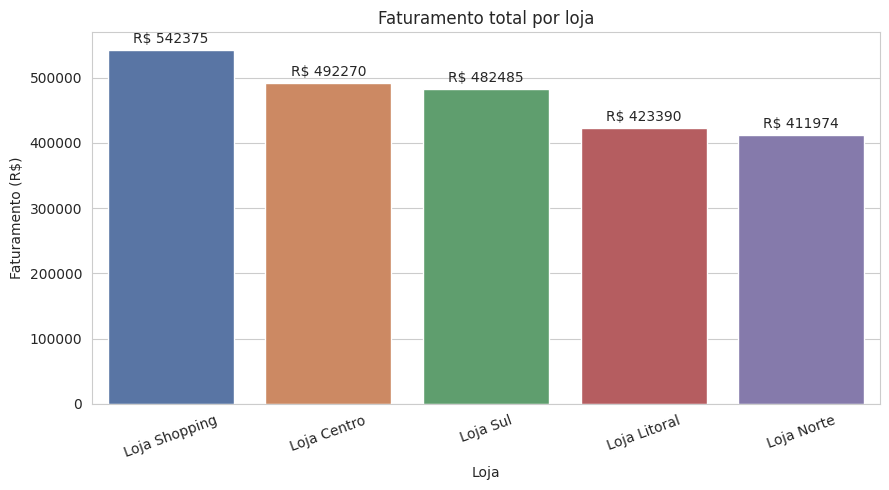

In [15]:
plt.figure(figsize=(9, 5))
ax = sns.barplot(x=fat_loja.index, y=fat_loja.values, hue=fat_loja.index, palette='deep', legend=False)
for c in ax.containers:
    ax.bar_label(c, fmt='R$ %.0f', padding=3)
plt.title('Faturamento total por loja')
plt.xlabel('Loja')
plt.ylabel('Faturamento (R$)')
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig('graficos/faturamento_por_loja.png', dpi=150)
plt.show()

### 12) Gráfico de linhas — Evolução mensal do faturamento

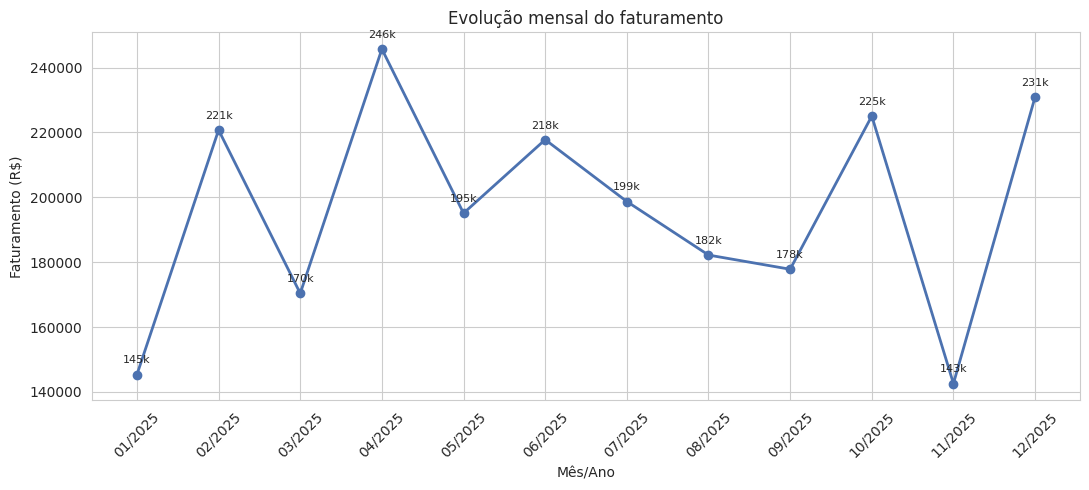

In [16]:
resumo_mensal = fat_mensal.reset_index()
resumo_mensal['rotulo'] = resumo_mensal['ano_mes'].dt.strftime('%m/%Y')

plt.figure(figsize=(11, 5))
plt.plot(resumo_mensal['rotulo'], resumo_mensal['faturamento'], marker='o', linewidth=2)
for x, y in zip(resumo_mensal['rotulo'], resumo_mensal['faturamento']):
    plt.annotate(f'{y/1000:.0f}k', (x, y), textcoords='offset points', xytext=(0, 8), ha='center', fontsize=8)
plt.title('Evolução mensal do faturamento')
plt.xlabel('Mês/Ano')
plt.ylabel('Faturamento (R$)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('graficos/evolucao_mensal.png', dpi=150)
plt.show()

### 13) Gráfico de pizza — Faturamento por região

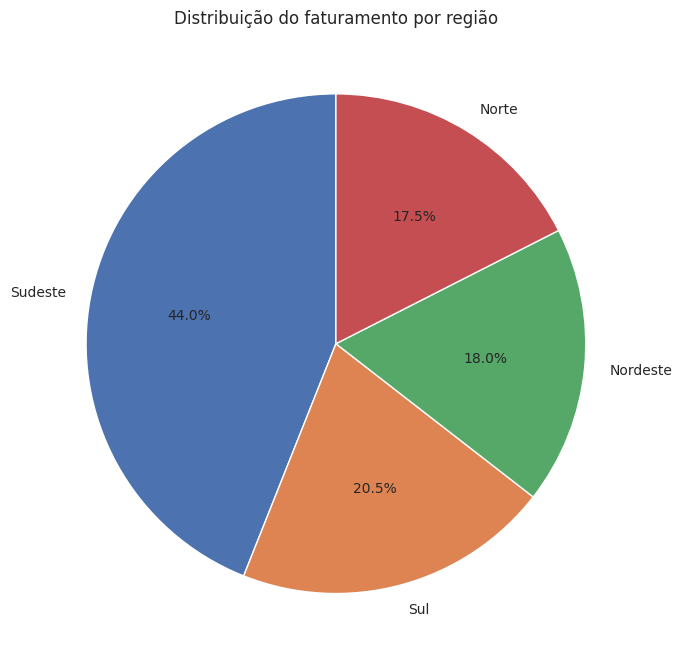

In [17]:
fat_regiao = df.groupby('regiao')['faturamento'].sum().sort_values(ascending=False)

plt.figure(figsize=(7, 7))
plt.pie(fat_regiao.values, labels=fat_regiao.index, autopct='%1.1f%%', startangle=90,
        colors=sns.color_palette('deep', len(fat_regiao)), wedgeprops={'edgecolor': 'white'})
plt.title('Distribuição do faturamento por região')
plt.tight_layout()
plt.savefig('graficos/faturamento_por_regiao.png', dpi=150)
plt.show()

### 14) Dispersão — Quantidade × Faturamento

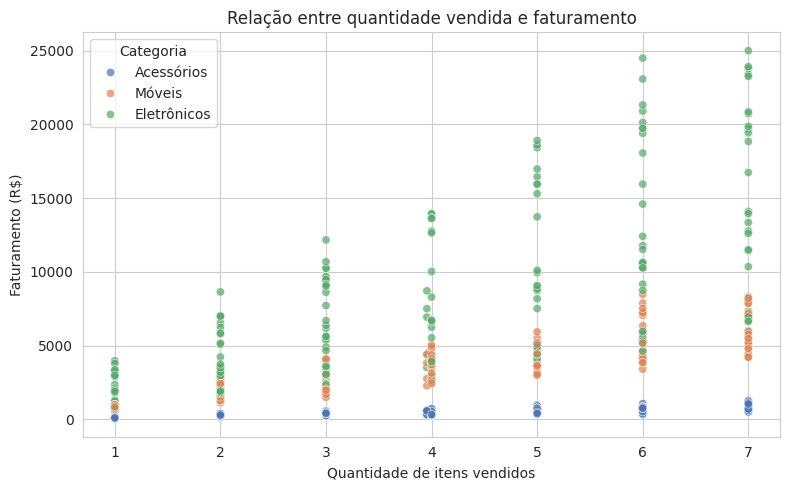

In [18]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='quantidade', y='faturamento', hue='categoria', alpha=0.7)
plt.title('Relação entre quantidade vendida e faturamento')
plt.xlabel('Quantidade de itens vendidos')
plt.ylabel('Faturamento (R$)')
plt.legend(title='Categoria')
plt.tight_layout()
plt.savefig('graficos/dispersao_quantidade_faturamento.png', dpi=150)
plt.show()

### 15) Boxplot — Preço unitário por categoria

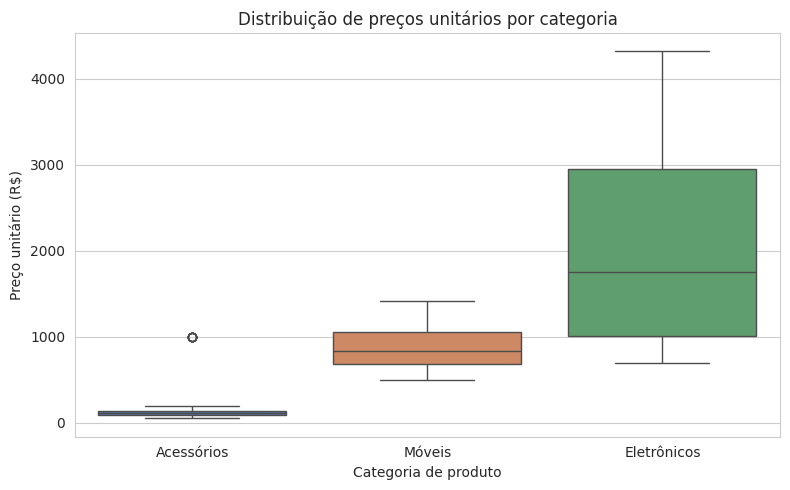

In [19]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='categoria', y='preco_unitario', hue='categoria', palette='deep', legend=False)
plt.title('Distribuição de preços unitários por categoria')
plt.xlabel('Categoria de produto')
plt.ylabel('Preço unitário (R$)')
plt.tight_layout()
plt.savefig('graficos/boxplot_preco_categoria.png', dpi=150)
plt.show()

### 16) Heatmap — Correlação entre variáveis numéricas

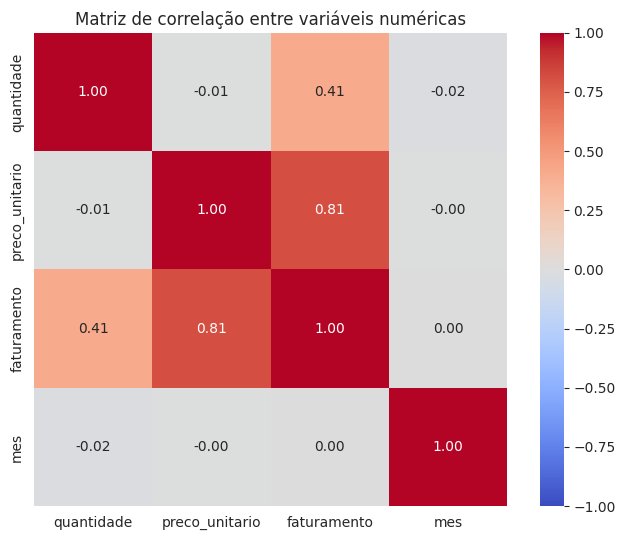

In [20]:
corr = df[['quantidade', 'preco_unitario', 'faturamento', 'mes']].corr()

plt.figure(figsize=(7, 5.5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, square=True)
plt.title('Matriz de correlação entre variáveis numéricas')
plt.tight_layout()
plt.savefig('graficos/heatmap_correlacao.png', dpi=150)
plt.show()

## Etapa 4 — Estilização e Apresentação
### 18) Rótulos e títulos
Todos os gráficos acima já possuem título descritivo, rótulos de eixos e legendas quando necessário (sem títulos genéricos como “Gráfico 1”).

### 19) Layout com múltiplos gráficos (`plt.subplots`)

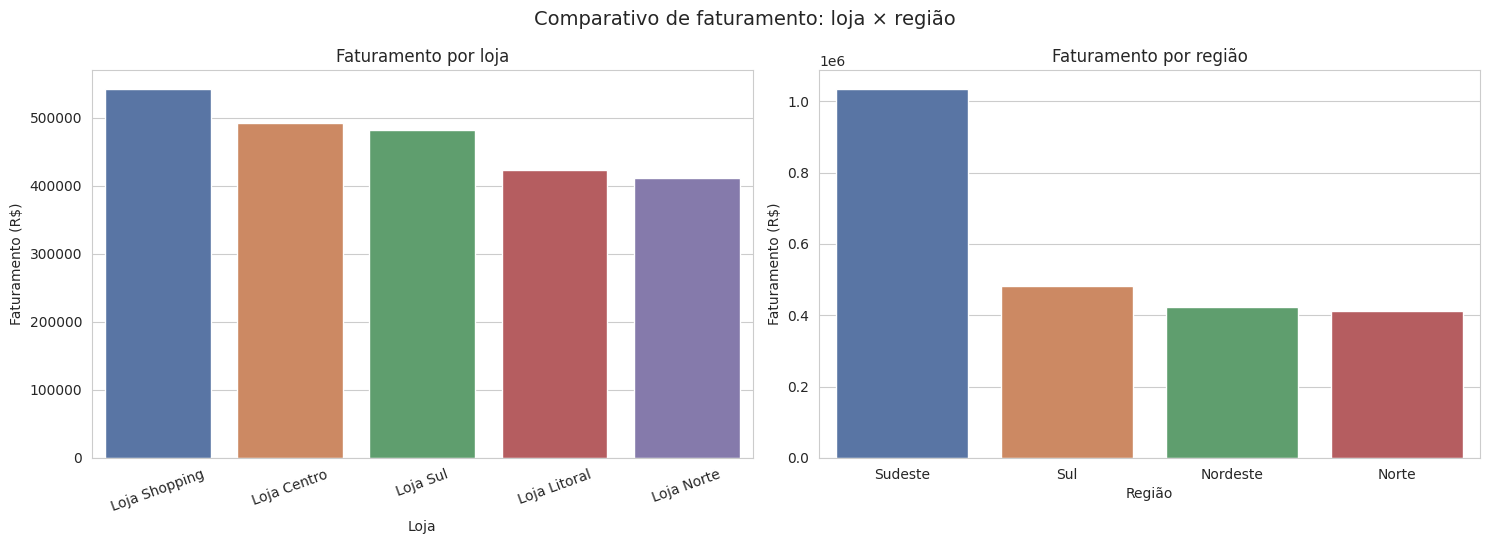

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

sns.barplot(x=fat_loja.index, y=fat_loja.values, hue=fat_loja.index, palette='deep', legend=False, ax=axes[0])
axes[0].set_title('Faturamento por loja')
axes[0].set_xlabel('Loja')
axes[0].set_ylabel('Faturamento (R$)')
axes[0].tick_params(axis='x', rotation=20)

sns.barplot(x=fat_regiao.index, y=fat_regiao.values, hue=fat_regiao.index, palette='deep', legend=False, ax=axes[1])
axes[1].set_title('Faturamento por região')
axes[1].set_xlabel('Região')
axes[1].set_ylabel('Faturamento (R$)')

fig.suptitle('Comparativo de faturamento: loja × região', fontsize=14)
plt.tight_layout()
plt.savefig('graficos/comparativo_loja_regiao.png', dpi=150)
plt.show()

### 20) Exportação e relatório final

In [22]:
resumo = pd.DataFrame({
    'faturamento_total': fat_loja,
    'ticket_medio': ticket,
    'quantidade_total': df.groupby('loja')['quantidade'].sum(),
    'numero_vendas': df.groupby('loja')['faturamento'].count(),
}).round(2).sort_values('faturamento_total', ascending=False)
resumo.index.name = 'loja'
resumo.to_csv('resumo_analitico.csv')

print('Gráficos salvos em graficos/:', sorted(os.listdir('graficos')))
resumo

Gráficos salvos em graficos/: ['boxplot_preco_categoria.png', 'comparativo_loja_regiao.png', 'dispersao_quantidade_faturamento.png', 'evolucao_mensal.png', 'faturamento_por_loja.png', 'faturamento_por_regiao.png', 'heatmap_correlacao.png']


,faturamento_total,ticket_medio,quantidade_total,numero_vendas
loja,,,,
Loja Shopping,542375.19,4140.27,505.91,131
Loja Centro,492269.84,4035.00,480.91,122
Loja Sul,482484.90,3600.63,535.91,134
Loja Litoral,423389.89,3618.72,459.87,117
Loja Norte,411974.38,4291.40,390.73,96


In [23]:
# Comentários automáticos sobre o que foi observado
print(f'• Loja com maior faturamento: {fat_loja.idxmax()} (R$ {fat_loja.max():,.2f}); menor: {fat_loja.idxmin()} (R$ {fat_loja.min():,.2f}).')
print(f'• Loja com maior ticket médio: {ticket.idxmax()} (R$ {ticket.max():,.2f}).')
print(f'• Região líder: {fat_regiao.idxmax()} com {fat_regiao.max()/fat_regiao.sum():.1%} do faturamento.')
print(f'• Melhor mês: {mes_max.strftime("%m/%Y")}; pior mês: {mes_min.strftime("%m/%Y")}.')
print(f'• Produto mais vendido em quantidade: {top5.index[0]} ({top5.iloc[0]:.0f} unidades).')
print(f'• Correlação quantidade × faturamento: {corr.loc["quantidade", "faturamento"]:.2f}; preço × faturamento: {corr.loc["preco_unitario", "faturamento"]:.2f}.')

• Loja com maior faturamento: Loja Shopping (R$ 542,375.19); menor: Loja Norte (R$ 411,974.38).
• Loja com maior ticket médio: Loja Norte (R$ 4,291.40).
• Região líder: Sudeste com 44.0% do faturamento.
• Melhor mês: 04/2025; pior mês: 11/2025.
• Produto mais vendido em quantidade: Mesa de Escritório (329 unidades).
• Correlação quantidade × faturamento: 0.41; preço × faturamento: 0.81.


### Comentários sobre o que foi observado
*(baseados no dataset fictício gerado; se usar outro CSV, reveja os números impressos acima)*

- **Lojas:** a Loja Shopping lidera em faturamento total, e a Loja Norte tem o menor total, mas o **maior ticket médio** – vende menos vezes, porém com valor mais alto por venda.
- **Regiões:** o Sudeste concentra a maior fatia do faturamento (duas lojas do dataset estão nessa região).
- **Sazonalidade:** o faturamento oscila bastante ao longo do ano, com pico em abril e queda acentuada em novembro; vale investigar campanhas ou estoque nesses meses.
- **Correlações:** o faturamento tem correlação mais forte com o **preço unitário** do que com a **quantidade**, ou seja, o valor dos produtos pesa mais no resultado do que o volume de itens.
- **Boxplot e dispersão:** a categoria Eletrônicos tem preços bem mais altos e dispersos, e os pontos mais altos do gráfico de dispersão (possíveis outliers) vêm dela.